# 10 — Customer Prediction Scoring

**Tujuan notebook ini (Fase 10 roadmap):**
- Score seluruh eligible population pakai model final (Logistic Regression)
- Output utama: **probability**, bukan label kategori langsung
- Threshold ditentukan sadar (Top-N / business capacity), bukan `> 0.5` sembarangan
- Gabungkan dengan **`customer_value_observation`** (bukan `customer_value` polos) — information set yang sama dengan feature model
- Simpan `threshold_used` & `threshold_method` di tiap record, supaya bisa dipertanggungjawabkan


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

DATA_DIR = Path("../data_processed")
MODELS_DIR = Path("../models")

ml_dataset = pd.read_csv(DATA_DIR / "ml_dataset_observation.csv", parse_dates=["last_order_date_observation"])

with open(MODELS_DIR / "logistic_regression.pkl", "rb") as f:
    final_model = pickle.load(f)

print(f"Model final: Logistic Regression")
print(f"ml_dataset shape: {ml_dataset.shape}")


Model final: Logistic Regression
ml_dataset shape: (54738, 10)


---
## 1. Score Seluruh Eligible Population

Model di-apply ke SEMUA customer di `ml_dataset_observation` (bukan cuma test set) — untuk scoring production-style, kita ingin probability untuk seluruh populasi yang eligible, bukan cuma subset yang dipakai evaluasi.


In [2]:
feature_cols = [
    "order_count", "total_spending", "avg_order_value", "avg_review_score",
    "avg_delivery_days", "unique_categories", "days_since_last_order",
]

X_all = ml_dataset[feature_cols]
ml_dataset["repeat_purchase_probability"] = final_model.predict_proba(X_all)[:, 1]

print(f"Probability berhasil dihitung untuk {len(ml_dataset):,} customer.")
print(f"\nDistribusi probability:")
print(ml_dataset["repeat_purchase_probability"].describe())


Probability berhasil dihitung untuk 54,738 customer.

Distribusi probability:
count    54738.000000
mean         0.482206
std          0.085454
min          0.000084
25%          0.428233
50%          0.487183
75%          0.537773
max          0.998548
Name: repeat_purchase_probability, dtype: float64


---
## 2. Tentukan Threshold — Berdasarkan Business Capacity / Top-N

**Bukan `probability > 0.50 = High`.** Sesuai temuan notebook 09: model paling efektif di Top 1-5% (lift 10.6x / 3.6x), jadi threshold yang dipakai adalah **Top-N by probability**, bukan angka fix.


In [3]:
TOP_N_PERCENT = 5  # sesuai lift terkuat yang ditemukan di notebook 09 (Top 5% -> lift 3.6x)
THRESHOLD_METHOD = f"top_{TOP_N_PERCENT}_percent"

threshold_value = ml_dataset["repeat_purchase_probability"].quantile(1 - TOP_N_PERCENT / 100)
ml_dataset["prediction"] = (ml_dataset["repeat_purchase_probability"] >= threshold_value).astype(int)
ml_dataset["threshold_used"] = round(threshold_value, 4)
ml_dataset["threshold_method"] = THRESHOLD_METHOD

n_flagged = ml_dataset["prediction"].sum()
precision_at_threshold = ml_dataset.loc[ml_dataset["prediction"] == 1, "target"].mean()

print(f"Threshold method : {THRESHOLD_METHOD}")
print(f"Threshold value  : {threshold_value:.4f}")
print(f"Customer di-flag : {n_flagged:,} dari {len(ml_dataset):,} ({n_flagged/len(ml_dataset)*100:.2f}%)")
print(f"Precision di threshold ini (dari data historis): {precision_at_threshold*100:.2f}%")
print(f"Baseline (positive rate keseluruhan): {ml_dataset['target'].mean()*100:.2f}%")


Threshold method : top_5_percent
Threshold value  : 0.5987
Customer di-flag : 2,737 dari 54,738 (5.00%)
Precision di threshold ini (dari data historis): 3.32%
Baseline (positive rate keseluruhan): 1.21%


> **Catatan dokumentasi:** threshold ini dipilih berdasarkan Top 5% by probability, bukan cutoff probability tetap — konsisten dengan insight lift terkuat di notebook 09. Kalau kapasitas tim marketing berubah (misal cuma sanggup 1% atau 10%), `TOP_N_PERCENT` di atas tinggal disesuaikan dan threshold otomatis ikut berubah — bukan menebak ulang dari nol.


---
## 3. Gabungkan dengan `customer_value_observation`

**Bukan `customer_value` polos** — `total_spending` yang sudah dihitung di observation window (sama information set dengan feature model) yang dipakai sebagai proxy customer value untuk Priority Matrix nanti (Fase 12).


In [4]:
ml_dataset["customer_value_observation"] = ml_dataset["total_spending"]

# Value band sederhana untuk preview Priority Matrix (median split, bisa disesuaikan)
value_median = ml_dataset["customer_value_observation"].median()
ml_dataset["value_band"] = np.where(
    ml_dataset["customer_value_observation"] >= value_median, "High Value", "Low Value"
)

print("Preview Priority Matrix (jumlah customer per kuadran):")
priority_matrix_preview = pd.crosstab(
    ml_dataset["value_band"],
    ml_dataset["prediction"].map({1: "High Probability", 0: "Low Probability"})
)
print(priority_matrix_preview)


Preview Priority Matrix (jumlah customer per kuadran):
prediction  High Probability  Low Probability
value_band                                   
High Value              1471            25903
Low Value               1266            26098


---
## 4. Output Final — Customer Prediction Scoring


In [5]:
scoring_output = ml_dataset[[
    "customer_unique_id", "repeat_purchase_probability", "prediction",
    "threshold_used", "threshold_method", "customer_value_observation", "value_band",
]].copy()

scoring_output = scoring_output.sort_values("repeat_purchase_probability", ascending=False)

print("Preview 10 customer dengan probability tertinggi:")
scoring_output.head(10)


Preview 10 customer dengan probability tertinggi:


,customer_unique_id,repeat_purchase_probability,prediction,threshold_used,threshold_method,customer_value_observation,value_band
13362,3e43e6105506432c953e165fb2acf44c,0.998548,1,0.5987,top_5_percent,1172.66,High Value
30165,8d50f5eadf50201ccdcedfb9e2ac8455,0.998318,1,0.5987,top_5_percent,503.54,High Value
5843,1b6c7548a2a1f9037c1fd3ddfed95f33,0.993663,1,0.5987,top_5_percent,959.01,High Value
15415,47c1a3033b8b77b3ab6e109eb4d5fdf3,0.987175,1,0.5987,top_5_percent,944.21,High Value
21503,6469f99c1f9dfae7733b25662e7f1782,0.985811,1,0.5987,top_5_percent,726.18,High Value
47714,de34b16117594161a6a89c50b289d35a,0.983020,1,0.5987,top_5_percent,660.94,High Value
21372,63cfc61cee11cbe306bff5857d00bfe4,0.971247,1,0.5987,top_5_percent,723.28,High Value
47324,dc813062e0fc23409cd255f7f53c7074,0.969014,1,0.5987,top_5_percent,972.55,High Value
51535,f0e310a6839dce9de1638e0fe5ab282a,0.961420,1,0.5987,top_5_percent,488.16,High Value
28853,86df00dc5fd68f4dd5d5945ca19f3ed6,0.953120,1,0.5987,top_5_percent,2400.48,High Value


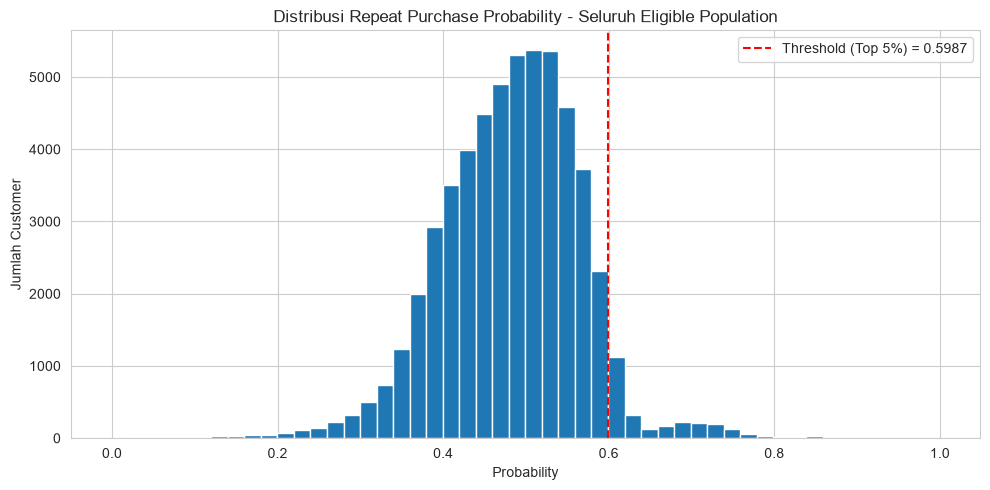

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ml_dataset["repeat_purchase_probability"], bins=50)
ax.axvline(threshold_value, color="red", linestyle="--", label=f"Threshold (Top {TOP_N_PERCENT}%) = {threshold_value:.4f}")
ax.set_title("Distribusi Repeat Purchase Probability - Seluruh Eligible Population")
ax.set_xlabel("Probability")
ax.set_ylabel("Jumlah Customer")
ax.legend()
plt.tight_layout()
plt.show()


---
## 5. Simpan Hasil Scoring

Disimpan sebagai CSV di `data_processed/` — akan dipakai lagi di notebook `11_export_for_powerbi.ipynb` dan disimpan ke MongoDB `customer_predictions` collection di Fase 11.


In [7]:
scoring_output.to_csv(DATA_DIR / "customer_predictions.csv", index=False)
print(f"Tersimpan: {DATA_DIR / 'customer_predictions.csv'}")
print(f"Shape: {scoring_output.shape}")
print(f"\nKolom: {list(scoring_output.columns)}")


Tersimpan: ..\data_processed\customer_predictions.csv
Shape: (54738, 7)

Kolom: ['customer_unique_id', 'repeat_purchase_probability', 'prediction', 'threshold_used', 'threshold_method', 'customer_value_observation', 'value_band']


---
## Definition of Done (Fase 10)

- [ ] Seluruh eligible population di-score (bukan cuma test set)
- [ ] Output utama `repeat_purchase_probability`, label `prediction` diturunkan dari threshold, bukan sebaliknya
- [ ] Threshold ditentukan berdasarkan Top-N/business capacity (Top 5%, sesuai lift terkuat), BUKAN `> 0.50` sembarangan
- [ ] `threshold_used` & `threshold_method` disimpan di tiap record — bisa dipertanggungjawabkan
- [ ] `customer_value_observation` dipakai (bukan `customer_value` full-history) — information set konsisten dengan feature model
- [ ] Hasil scoring tersimpan sebagai `customer_predictions.csv`

**Lanjut ke:** `11_export_for_powerbi.ipynb` — lalu simpan hasil scoring ini ke MongoDB `customer_predictions` collection (Fase 11).
